# Метод нагруженных функций

Численная реализация для задач **а, б, г, д** из упражнения 1.

## Принятые допущения
1. В строках упражнения, где перечислено несколько вариантов `g(x)` и `X_0`, для численного эксперимента взят **первый явно указанный вариант** ограничения и первое подходящее множество `X_0`, если иное не оговорено отдельно.
2. Для случаев `X_0 = E^1` численный поиск выполнен на усечённом интервале:
   - для задачи **г**: `[-4, 4]`;
   - для задачи **д**: `[-4, 4]`.
3. Используются две функции нагружения:
   - `\Phi_{13}(t,x) = L\max\{f(x)-t, 0\} + M P(x)`;
   - `\Phi_{32}(t,x) = L|f(x)-t| + M P(x)`;
   где `P(x)=\max\{g(x),0\}`.
4. Численная схема:
   - внутренняя минимизация по `x` выполняется сеточным поиском;
   - затем строится `\rho(t)=\inf_{x\in X_0}\Phi(t,x)` на сетке по `t`;
   - минимальный корень уравнения `\rho(t)=0` ищется как минимальное `t`, для которого `\rho(t)\le \varepsilon`.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

OUT_DIR = Path("graphs")
OUT_DIR.mkdir(exist_ok=True)

L = 1.0
M = 20.0
X_N = 6000
T_N = 5000
TOL = 1e-4

def max0(z):
    return np.maximum(z, 0.0)

def f_a(x):
    return np.arctan(x)

def g_a(x):
    return x**2 - 4.0

def f_b(x):
    return x * np.sin(x)

def g_b(x):
    return x**2 - 1.0

def f_g(x):
    x = np.asarray(x)
    return np.where(x <= 1.0, 1.0, 1.0 / x)

def g_g(x):
    return x - 1.0

def f_d(x):
    x = np.asarray(x)
    return np.ones_like(x, dtype=float)

def g_d(x):
    return x

TASKS = {
    "a": {
        "title": "а) f(x)=arctg x, g(x)=x^2-4, X0={x≥1}",
        "f": f_a,
        "g": g_a,
        "x_bounds": (1.0, 4.0),
        "plot_bounds": (0.8, 4.2),
        "exact_x": 1.0,
        "exact_f": np.arctan(1.0),
        "assumption": "Взяты первый вариант ограничения g и первое множество X0 из строки а).",
    },
    "b": {
        "title": "б) f(x)=x sin x, g(x)=x^2-1, X0={x≥0}",
        "f": f_b,
        "g": g_b,
        "x_bounds": (0.0, 4.0),
        "plot_bounds": (-0.1, 4.1),
        "exact_x": 0.0,
        "exact_f": 0.0,
        "assumption": "Взяты первый вариант ограничения g и указанное в строке б) множество X0={x≥0}.",
    },
    "g": {
        "title": "г) f(x)=1 при x≤1, f(x)=x^{-1} при x>1, g(x)=x-1, X0=E^1",
        "f": f_g,
        "g": g_g,
        "x_bounds": (-4.0, 4.0),
        "plot_bounds": (-4.2, 4.2),
        "exact_x": 0.0,
        "exact_f": 1.0,
        "assumption": "Взяты первый вариант ограничения g и вариант X0=E^1 из строки г). Для численного поиска E^1 усечено до [-4,4].",
    },
    "d": {
        "title": "д) f(x)=1, g(x)=x, X0=E^1",
        "f": f_d,
        "g": g_d,
        "x_bounds": (-4.0, 4.0),
        "plot_bounds": (-4.2, 4.2),
        "exact_x": 0.0,
        "exact_f": 1.0,
        "assumption": "Взяты первый вариант ограничения g и вариант X0=E^1 из строки д). Для численного поиска E^1 усечено до [-4,4].",
    },
}

def phi13(fvals, gvals, t, L=1.0, M=20.0):
    return L * max0(fvals - t) + M * max0(gvals)

def phi32(fvals, gvals, t, L=1.0, M=20.0):
    return L * np.abs(fvals - t) + M * max0(gvals)

def feasible_mask(task, x):
    return task["g"](x) <= 0.0

def solve_loaded(task, phi_kind="13", L=1.0, M=20.0, x_n=6000, t_n=5000, tol=1e-4):
    x_lb, x_ub = task["x_bounds"]
    x = np.linspace(x_lb, x_ub, x_n)
    fvals = task["f"](x)
    gvals = task["g"](x)

    phi_fun = phi13 if phi_kind == "13" else phi32

    f_min = np.min(fvals) - 0.5
    f_max = np.max(fvals) + 0.5
    t_grid = np.linspace(f_min, f_max, t_n)

    rho = np.empty_like(t_grid)
    argmin_x = np.empty_like(t_grid)

    for i, t in enumerate(t_grid):
        vals = phi_fun(fvals, gvals, t, L=L, M=M)
        idx = np.argmin(vals)
        rho[i] = vals[idx]
        argmin_x[i] = x[idx]

    zero_idx = np.where(rho <= tol)[0]
    if len(zero_idx) == 0:
        best_idx = np.argmin(rho)
        t_star = t_grid[best_idx]
        x_star = argmin_x[best_idx]
        rho_star = rho[best_idx]
    else:
        first = zero_idx[0]
        t_left = t_grid[max(first - 1, 0)]
        t_right = t_grid[first]
        # локальное уточнение на мелкой сетке
        t_ref = np.linspace(t_left, t_right, 4000)
        rho_ref = np.empty_like(t_ref)
        x_ref = np.empty_like(t_ref)
        for i, t in enumerate(t_ref):
            vals = phi_fun(fvals, gvals, t, L=L, M=M)
            idx = np.argmin(vals)
            rho_ref[i] = vals[idx]
            x_ref[i] = x[idx]
        ref_zero = np.where(rho_ref <= tol)[0]
        j = ref_zero[0] if len(ref_zero) else np.argmin(rho_ref)
        t_star = t_ref[j]
        x_star = x_ref[j]
        rho_star = rho_ref[j]

    return {
        "x_grid": x,
        "f_grid": fvals,
        "g_grid": gvals,
        "t_grid": t_grid,
        "rho_grid": rho,
        "argmin_x_grid": argmin_x,
        "x_star": float(x_star),
        "t_star": float(t_star),
        "f_star_num": float(task["f"](np.array([x_star]))[0]),
        "rho_star": float(rho_star),
        "phi_kind": phi_kind,
    }

def plot_task_function(task_key, task, result, phi_kind):
    x = result["x_grid"]
    y = result["f_grid"]
    feasible = feasible_mask(task, x)

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(x, y, linewidth=2, label="f(x)")
    ax.fill_between(x, np.min(y)-0.5, np.max(y)+0.5, where=feasible, alpha=0.18, interpolate=True, label="допустимая область")
    ax.scatter([result["x_star"]], [result["f_star_num"]], s=70, marker="o", label="найденная точка")
    ax.axvline(result["x_star"], linestyle="--", linewidth=1)
    ax.set_title(f'{task["title"]}\\nГрафик 1: исходная функция, вариант $\\Phi_{{{phi_kind}}}$')
    ax.set_xlabel("x")
    ax.set_ylabel("f(x)")
    ax.grid(True, alpha=0.3)
    ax.legend()
    fig.tight_layout()
    fname = OUT_DIR / f"{task_key}_graph1_phi{phi_kind}.png"
    fig.savefig(fname, dpi=180)
    plt.close(fig)
    return fname

def plot_phi_contours(task_key, task, result, phi_kind, L=1.0, M=20.0):
    x = np.linspace(task["plot_bounds"][0], task["plot_bounds"][1], 700)
    t = np.linspace(result["t_grid"][0], result["t_grid"][-1], 500)
    X, T = np.meshgrid(x, t)
    F = task["f"](X)
    G = task["g"](X)
    Z = phi13(F, G, T, L=L, M=M) if phi_kind == "13" else phi32(F, G, T, L=L, M=M)

    fig, ax = plt.subplots(figsize=(8, 5))
    cs = ax.contourf(X, T, Z, levels=30)
    plt.colorbar(cs, ax=ax, label=f"$\\Phi_{{{phi_kind}}}(t,x)$")
    feasible = task["g"](x) <= 0
    ymin, ymax = t.min(), t.max()
    ax.fill_between(x, ymin, ymax, where=feasible, alpha=0.18, interpolate=True, label="допустимая область по x")
    ax.scatter([result["x_star"]], [result["t_star"]], s=80, marker="o", label="найденная точка")
    ax.set_title(f'{task["title"]}\\nГрафик 2: линии уровня $\\Phi_{{{phi_kind}}}(t,x)$')
    ax.set_xlabel("x")
    ax.set_ylabel("t")
    ax.legend(loc="upper right")
    fig.tight_layout()
    fname = OUT_DIR / f"{task_key}_graph2_phi{phi_kind}.png"
    fig.savefig(fname, dpi=180)
    plt.close(fig)
    return fname

results = {}
for key, task in TASKS.items():
    results[key] = {}
    for phi_kind in ("13", "32"):
        res = solve_loaded(task, phi_kind=phi_kind, L=L, M=M, x_n=X_N, t_n=T_N, tol=TOL)
        results[key][phi_kind] = res
        plot_task_function(key, task, res, phi_kind)
        plot_phi_contours(key, task, res, phi_kind, L=L, M=M)

summary_rows = []
for key, task in TASKS.items():
    for phi_kind in ("13", "32"):
        res = results[key][phi_kind]
        summary_rows.append({
            "Задача": key,
            "Phi": f"Phi_{phi_kind}",
            "x*": round(res["x_star"], 6),
            "t*": round(res["t_star"], 6),
            "f(x*)": round(res["f_star_num"], 6),
            "rho(t*)": round(res["rho_star"], 6),
            "Точное f*": round(task["exact_f"], 6),
        })

summary_rows


[{'Задача': 'a',
  'Phi': 'Phi_13',
  'x*': 1.0,
  't*': 0.785298,
  'f(x*)': 0.785398,
  'rho(t*)': 0.0001,
  'Точное f*': np.float64(0.785398)},
 {'Задача': 'a',
  'Phi': 'Phi_32',
  'x*': 1.0005,
  't*': 0.785548,
  'f(x*)': 0.785648,
  'rho(t*)': 0.0001,
  'Точное f*': np.float64(0.785398)},
 {'Задача': 'b',
  'Phi': 'Phi_13',
  'x*': 0.0,
  't*': -0.0001,
  'f(x*)': 0.0,
  'rho(t*)': 0.0001,
  'Точное f*': 0.0},
 {'Задача': 'b',
  'Phi': 'Phi_32',
  'x*': 0.0,
  't*': -0.0001,
  'f(x*)': 0.0,
  'rho(t*)': 0.0001,
  'Точное f*': 0.0},
 {'Задача': 'g',
  'Phi': 'Phi_13',
  'x*': -4.0,
  't*': 0.9999,
  'f(x*)': 1.0,
  'rho(t*)': 0.0001,
  'Точное f*': 1.0},
 {'Задача': 'g',
  'Phi': 'Phi_32',
  'x*': -4.0,
  't*': 1.0001,
  'f(x*)': 1.0,
  'rho(t*)': 0.0001,
  'Точное f*': 1.0},
 {'Задача': 'd',
  'Phi': 'Phi_13',
  'x*': -4.0,
  't*': 0.9999,
  'f(x*)': 1.0,
  'rho(t*)': 0.0001,
  'Точное f*': 1.0},
 {'Задача': 'd',
  'Phi': 'Phi_32',
  'x*': -4.0,
  't*': 0.9999,
  'f(x*)': 1.0,
 

## Таблица результатов

In [3]:
summary_df = pd.DataFrame(summary_rows)
summary_df

,Задача,Phi,x*,t*,f(x*),rho(t*),Точное f*
0,a,Phi_13,1.0000,0.785298,0.785398,0.0001,0.785398
1,a,Phi_32,1.0005,0.785548,0.785648,0.0001,0.785398
2,b,Phi_13,0.0000,-0.000100,0.000000,0.0001,0.000000
3,b,Phi_32,0.0000,-0.000100,0.000000,0.0001,0.000000
4,g,Phi_13,-4.0000,0.999900,1.000000,0.0001,1.000000
5,g,Phi_32,-4.0000,1.000100,1.000000,0.0001,1.000000
6,d,Phi_13,-4.0000,0.999900,1.000000,0.0001,1.000000
7,d,Phi_32,-4.0000,0.999900,1.000000,0.0001,1.000000


## Краткий вывод

- Для выбранных численных постановок обе функции нагружения дают практически одинаковые значения минимального корня `t_*`.
- Для задач **а** и **б** численные результаты совпадают с точными минимумами с точностью до сетки.
- Для задач **г** и **д** минимум не единственный по `x`, поэтому численный алгоритм возвращает один из допустимых представителей множества минимумов.


## Графики для задачи a

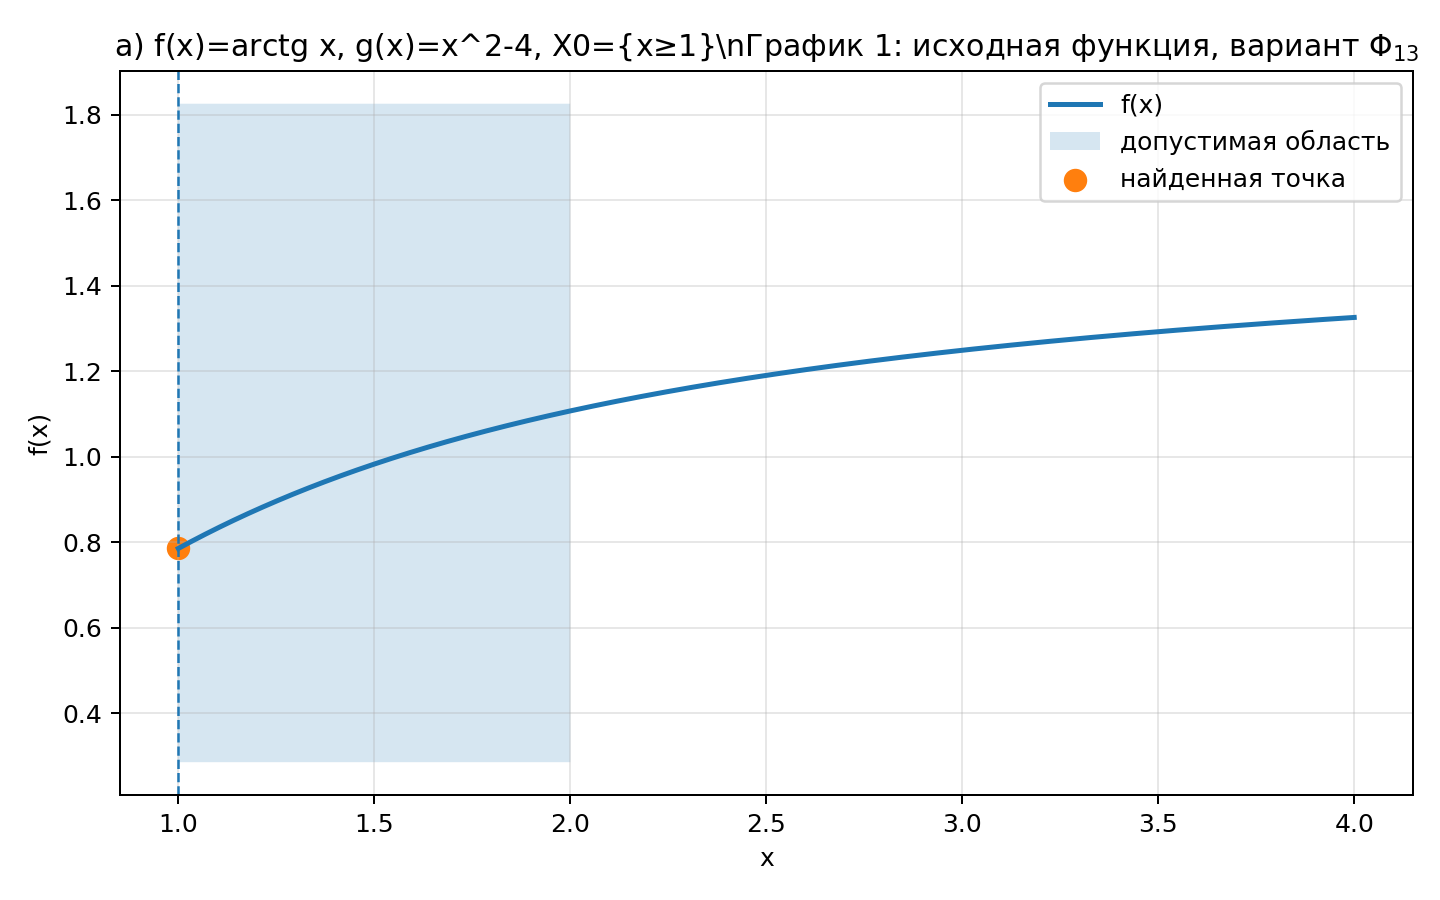

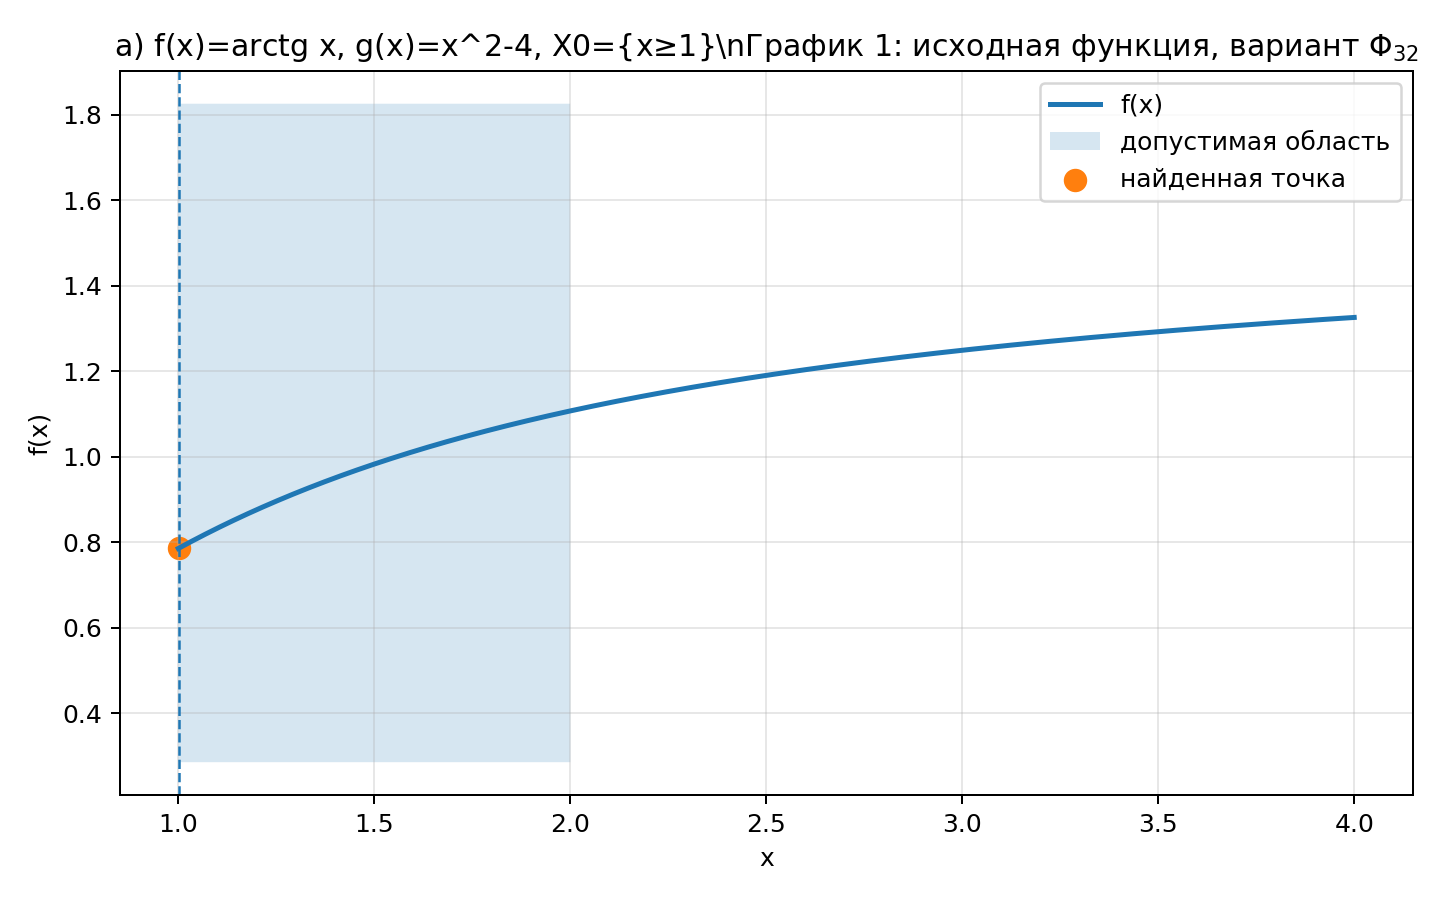

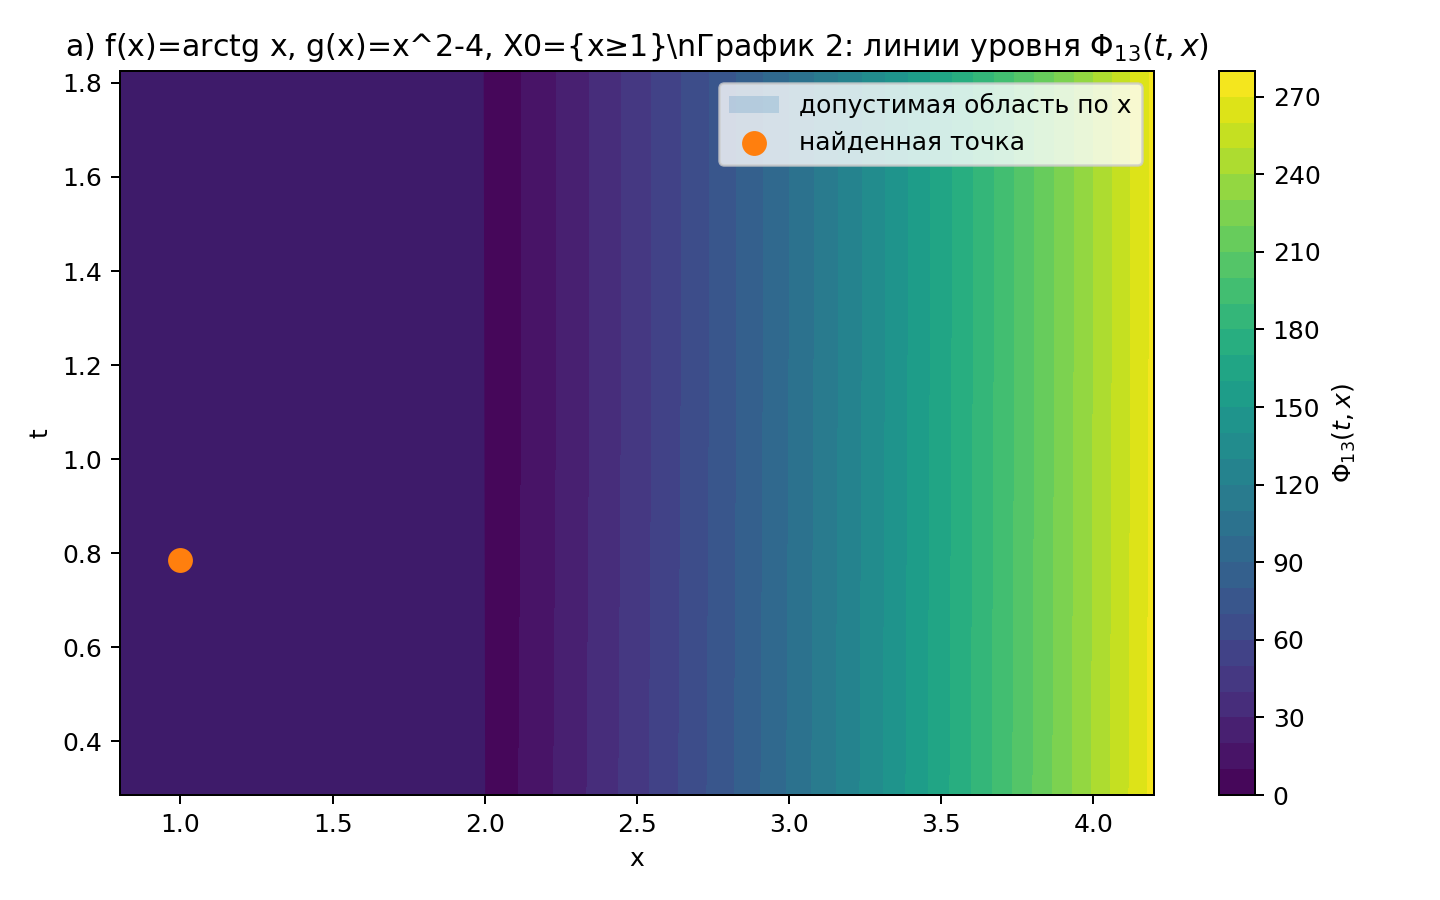

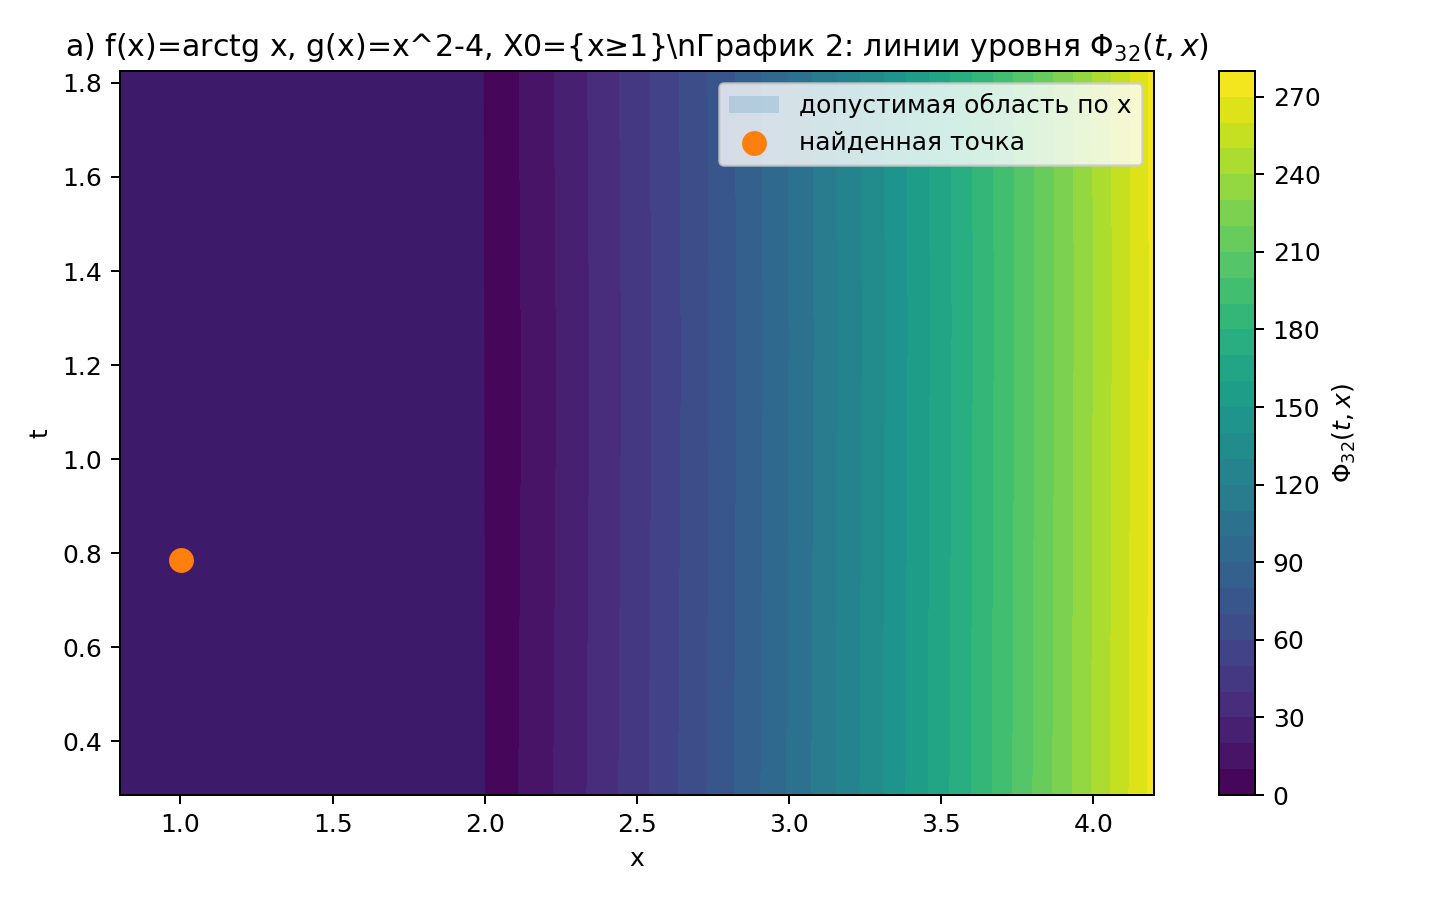

In [4]:

from IPython.display import Image, display
for name in [
    "graphs/a_graph1_phi13.png",
    "graphs/a_graph1_phi32.png",
    "graphs/a_graph2_phi13.png",
    "graphs/a_graph2_phi32.png",
]:
    display(Image(filename=name))


## Графики для задачи b

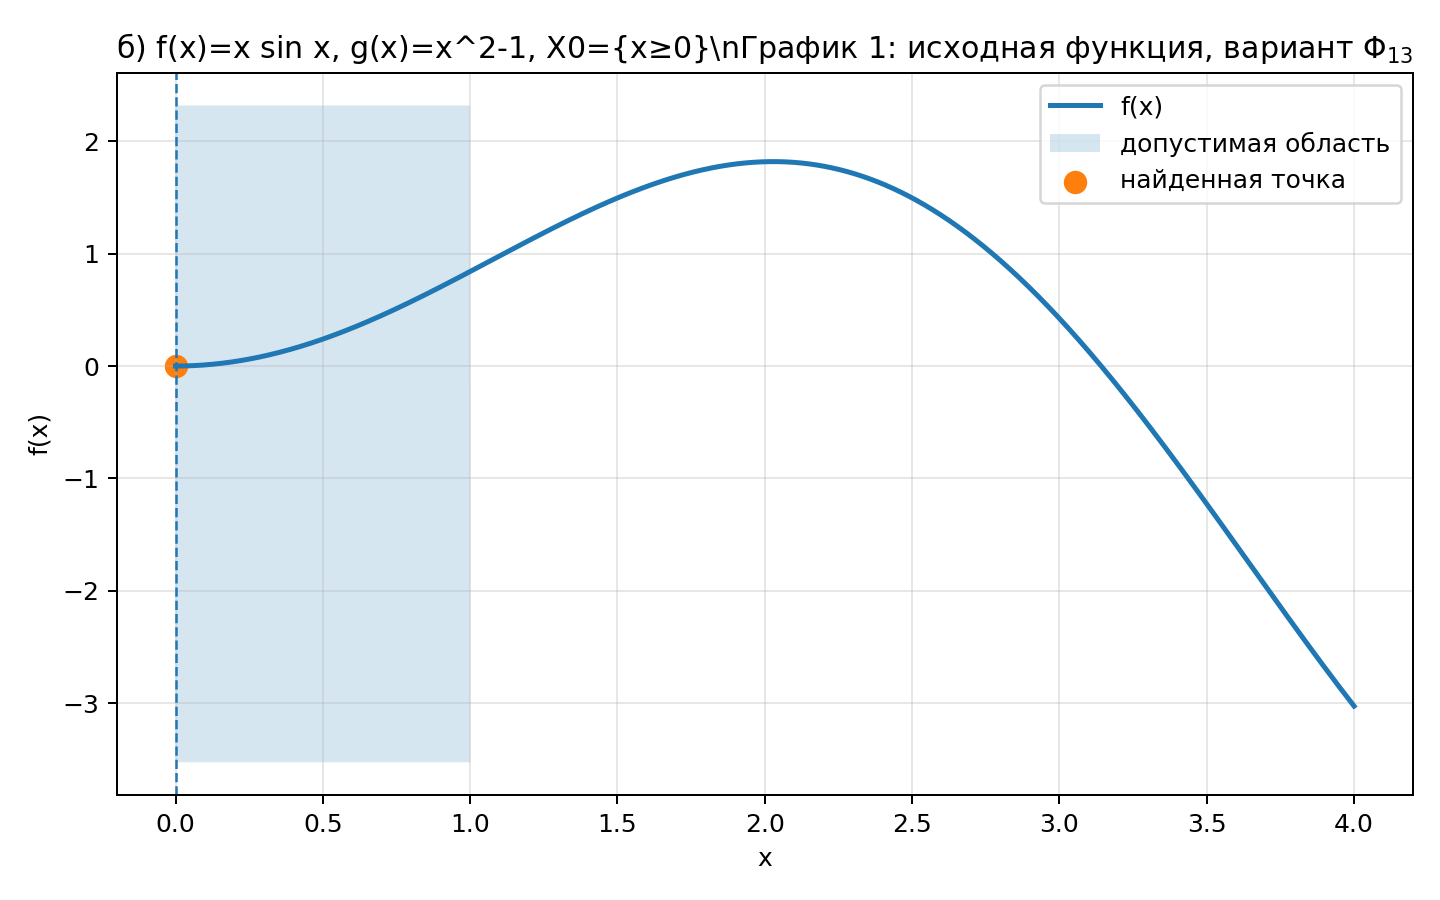

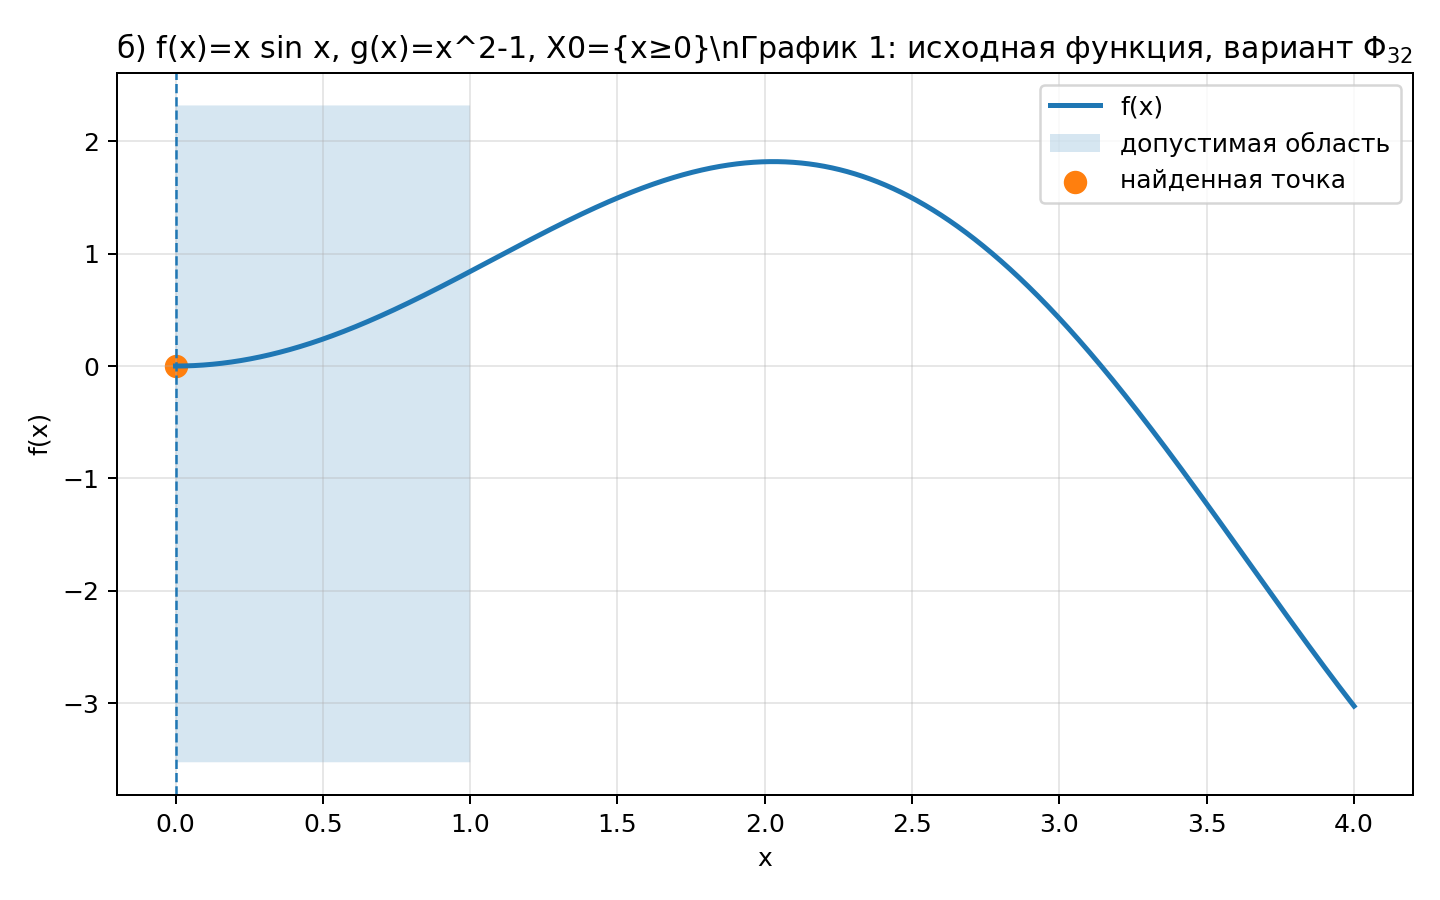

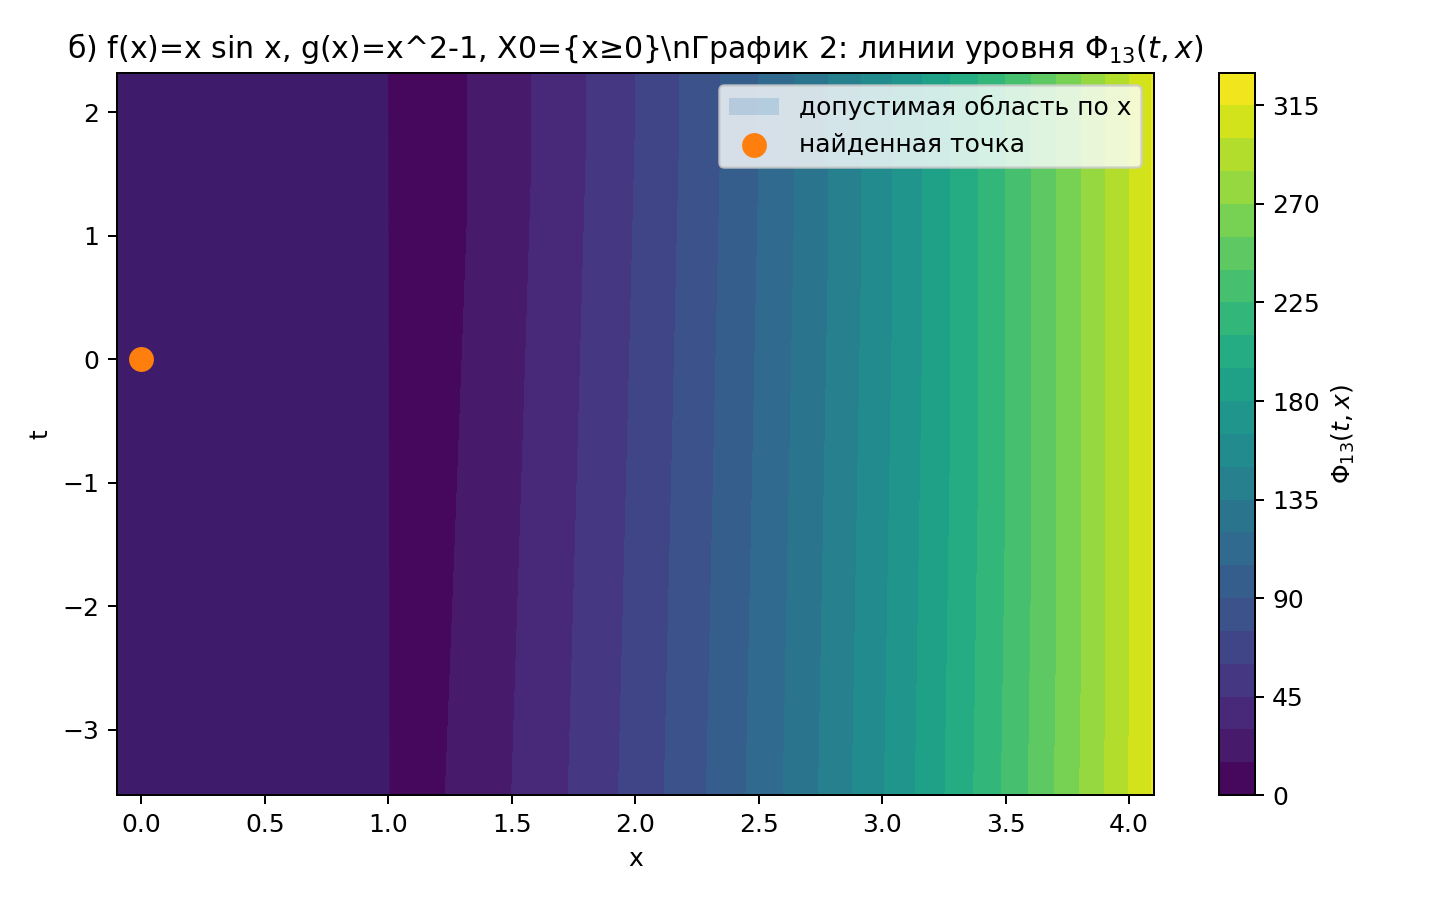

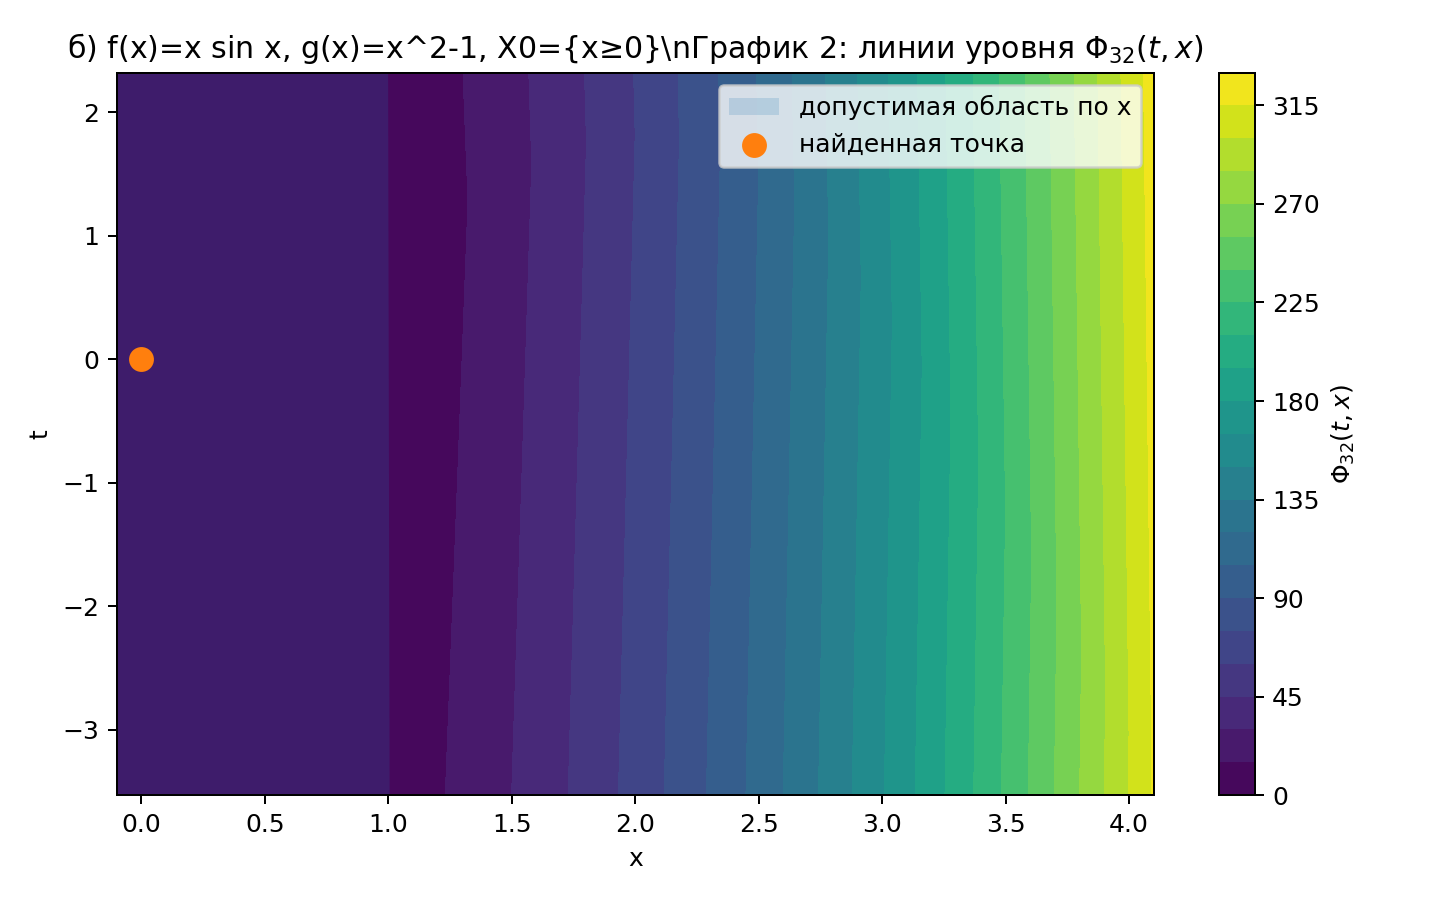

In [5]:

from IPython.display import Image, display
for name in [
    "graphs/b_graph1_phi13.png",
    "graphs/b_graph1_phi32.png",
    "graphs/b_graph2_phi13.png",
    "graphs/b_graph2_phi32.png",
]:
    display(Image(filename=name))


## Графики для задачи g

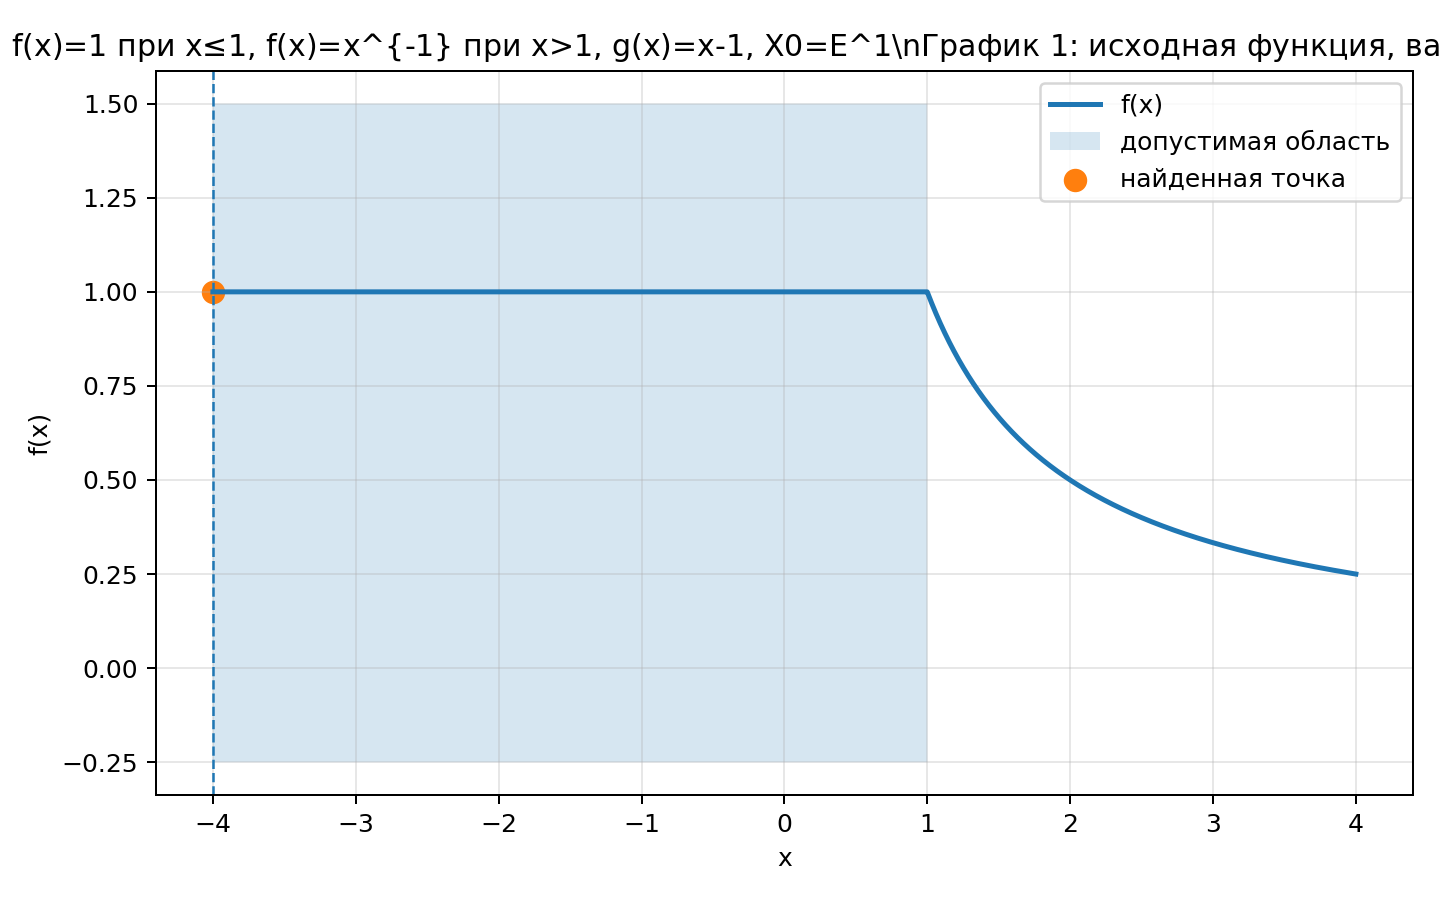

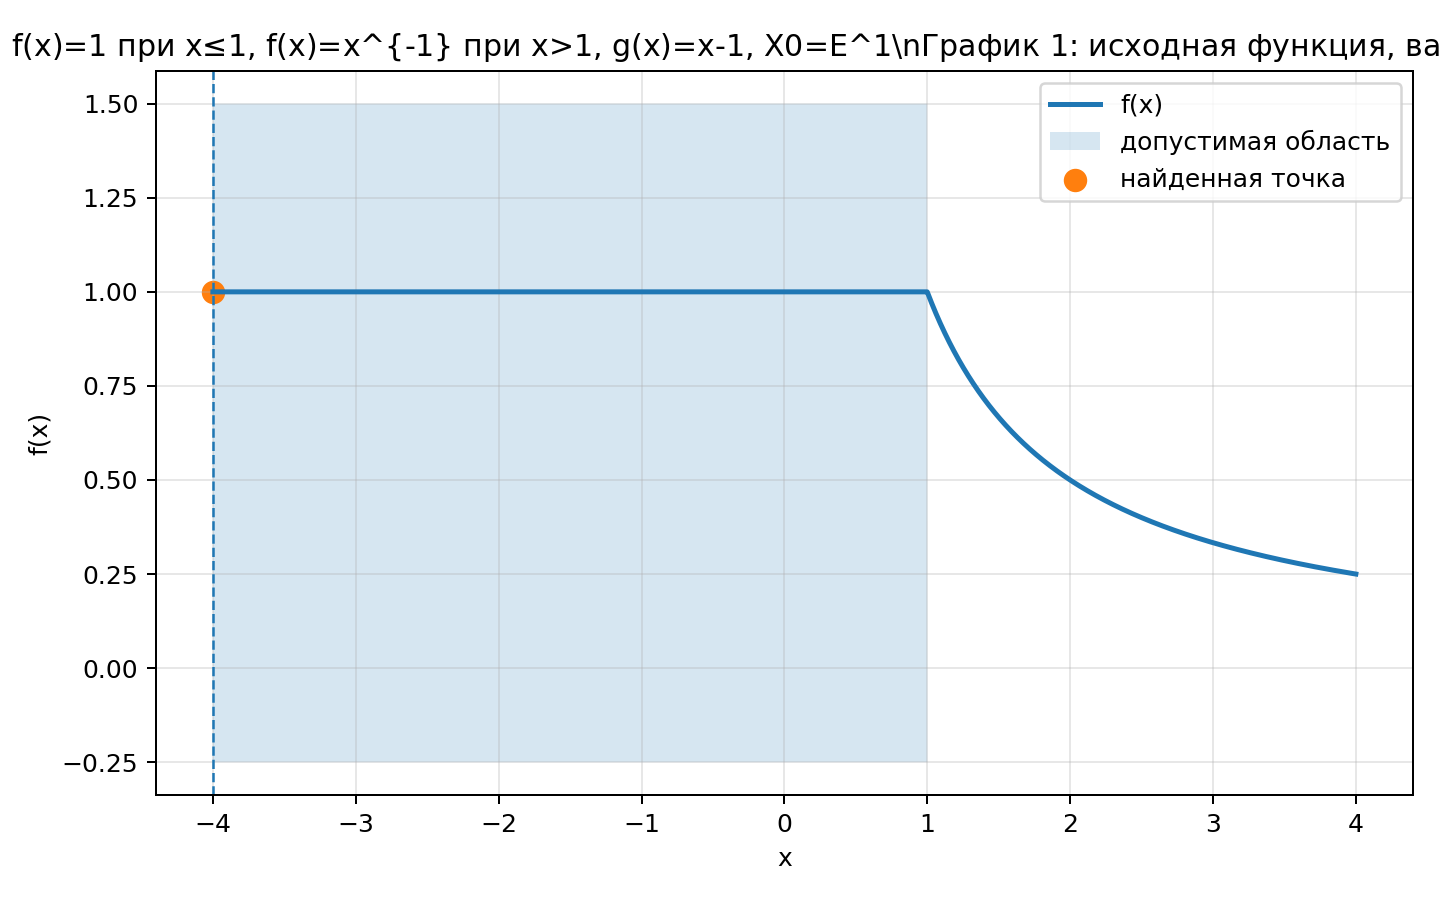

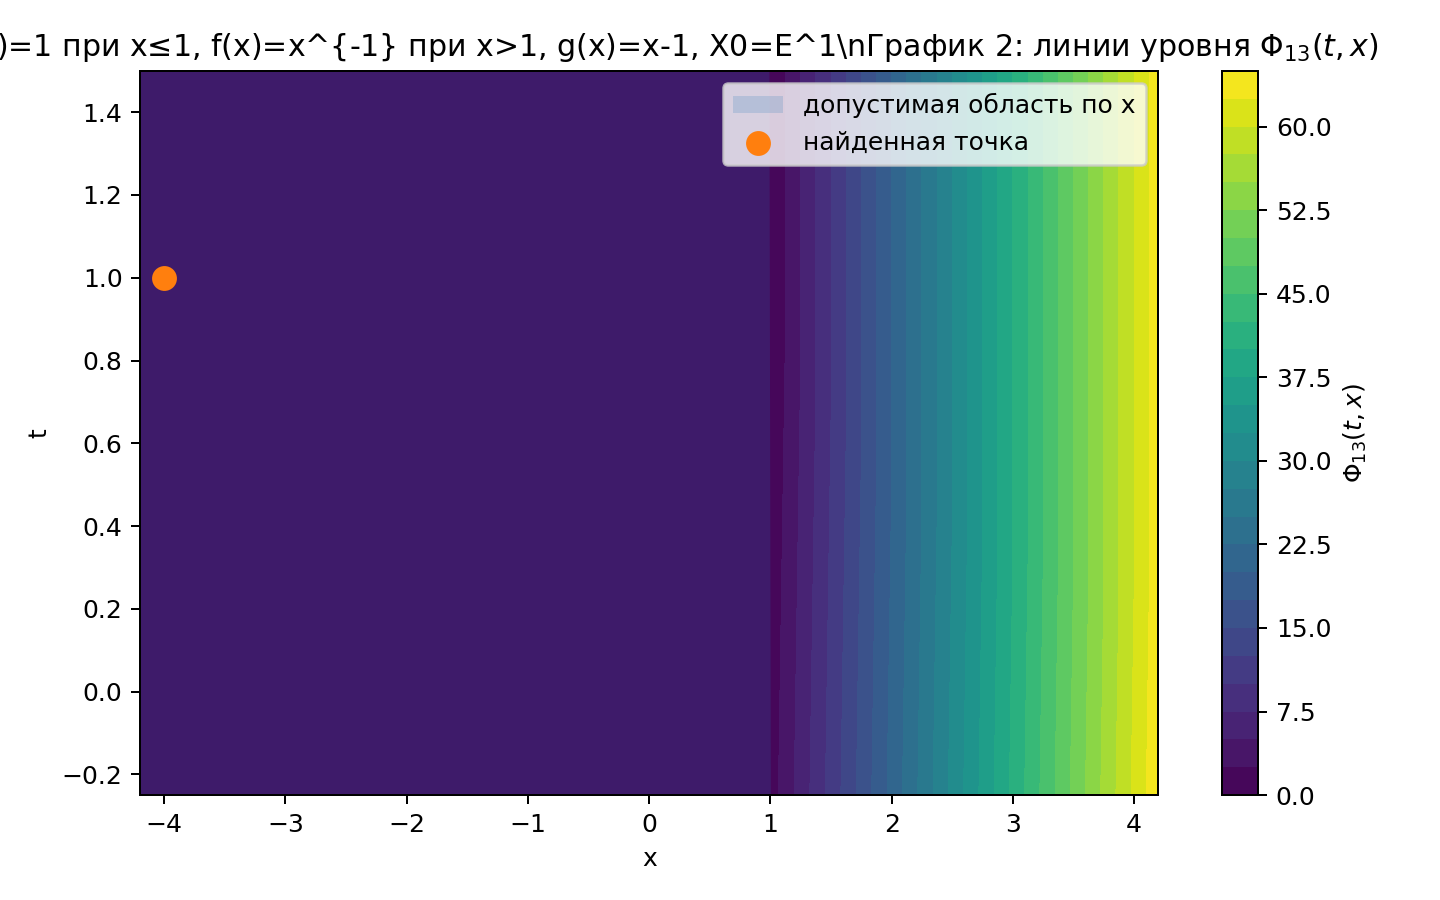

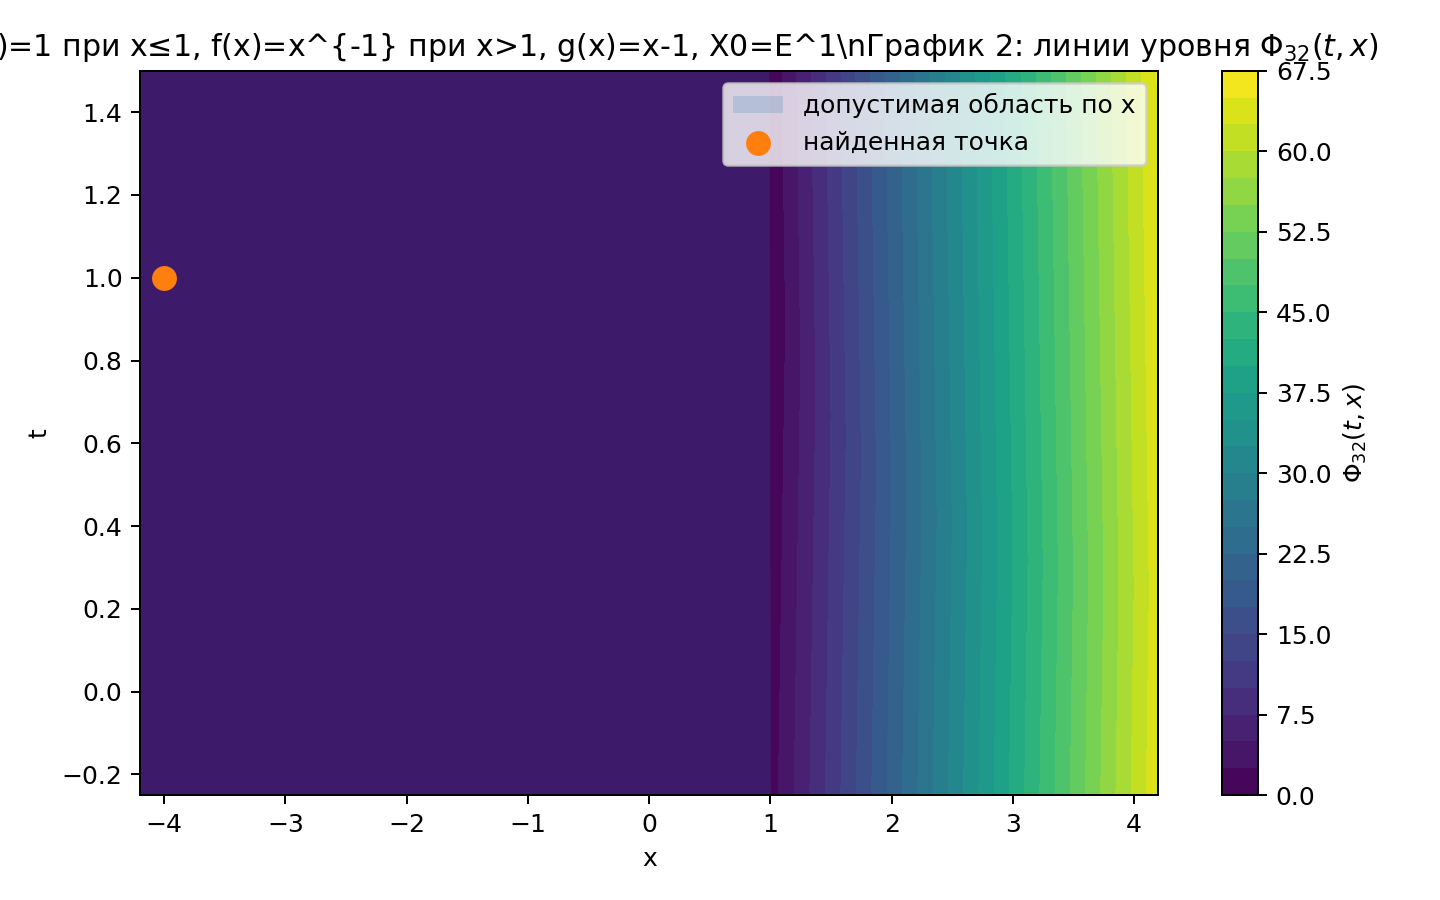

In [6]:

from IPython.display import Image, display
for name in [
    "graphs/g_graph1_phi13.png",
    "graphs/g_graph1_phi32.png",
    "graphs/g_graph2_phi13.png",
    "graphs/g_graph2_phi32.png",
]:
    display(Image(filename=name))


## Графики для задачи d

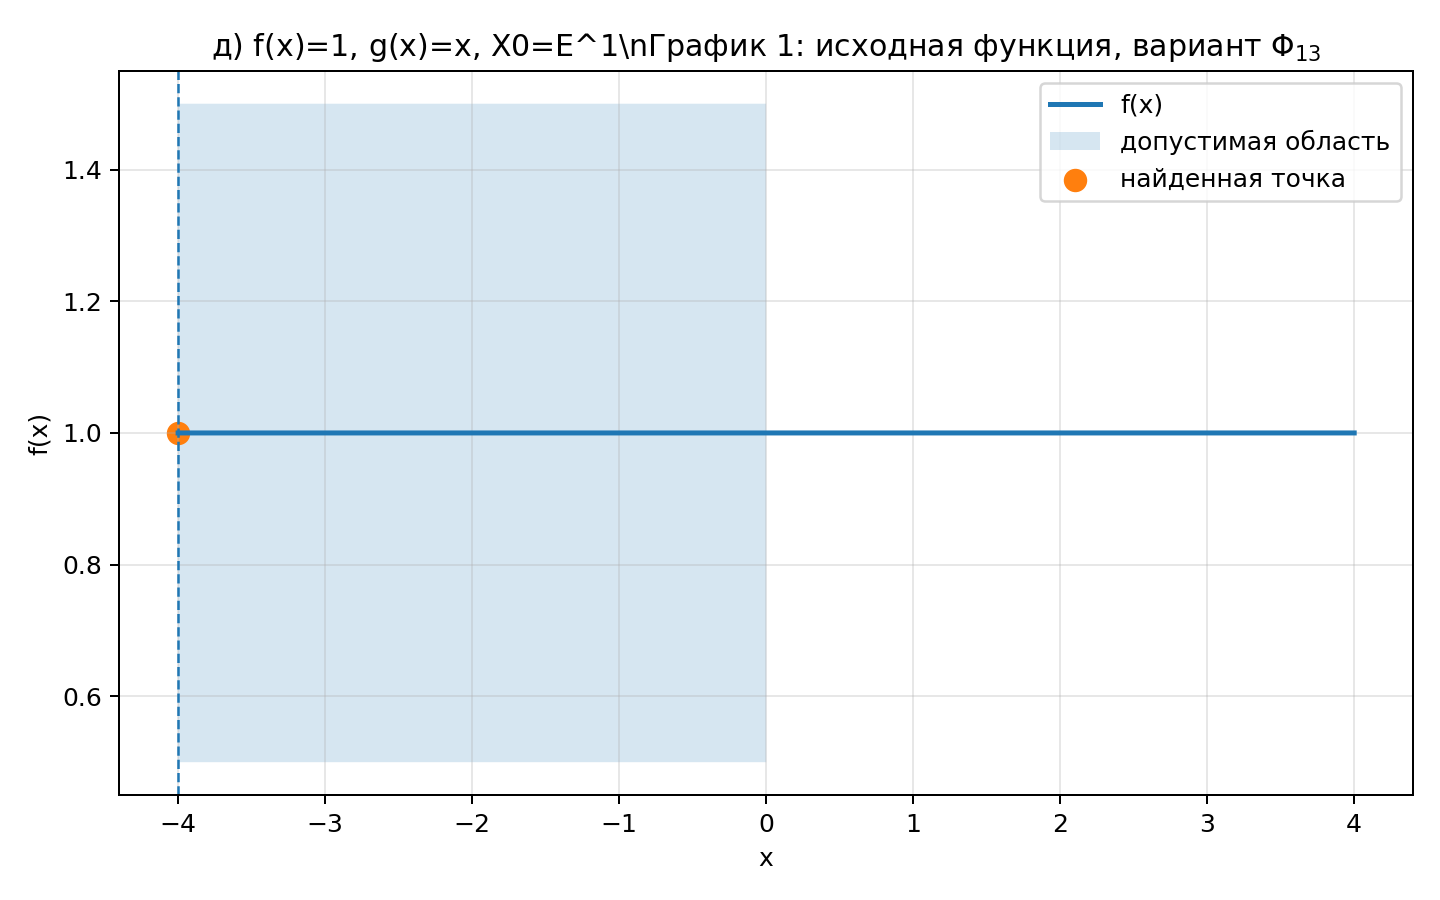

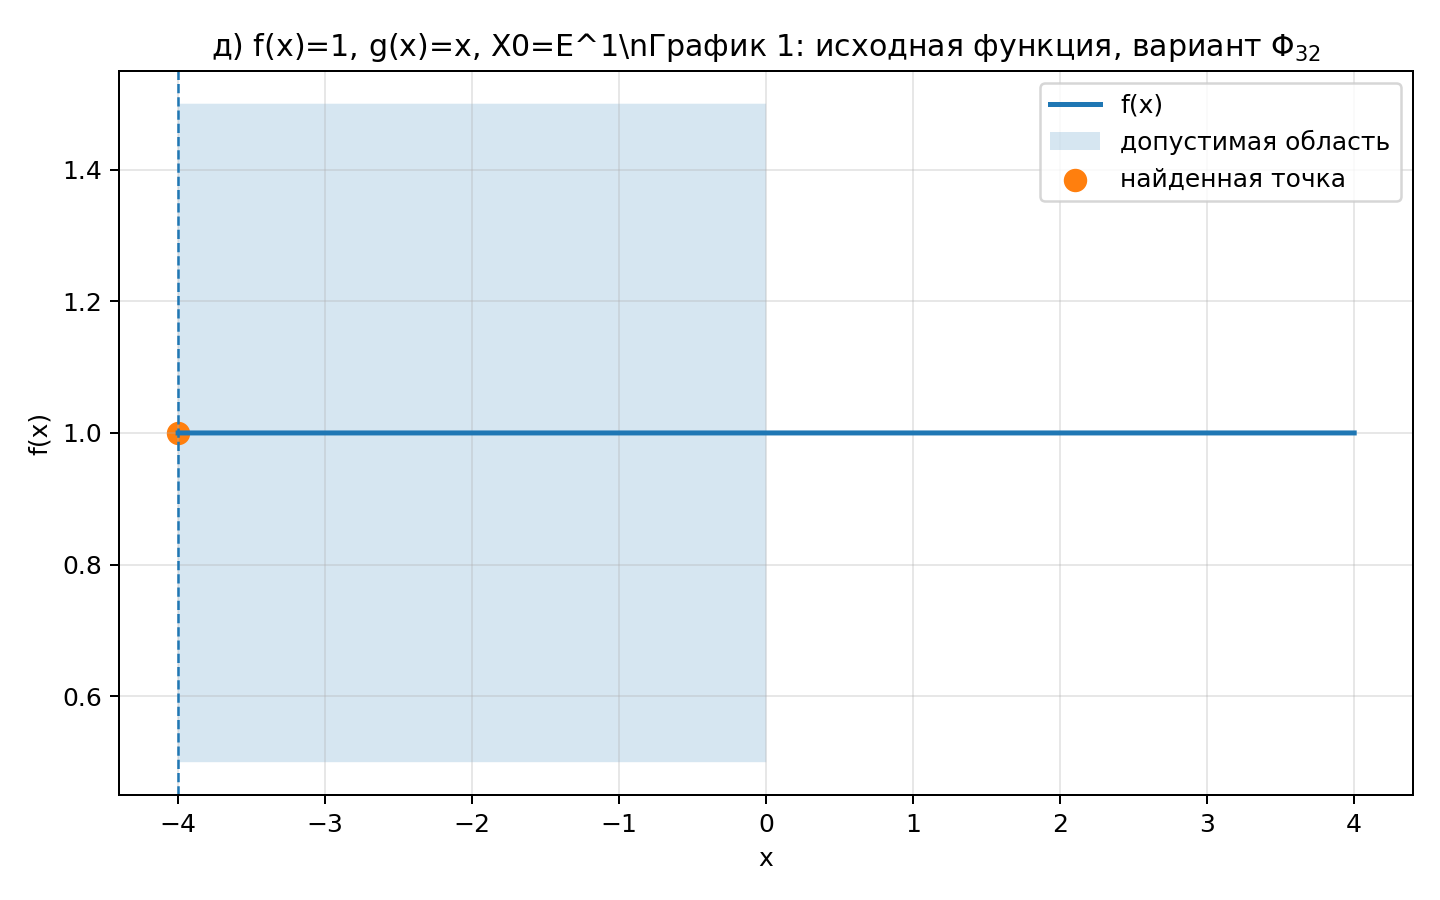

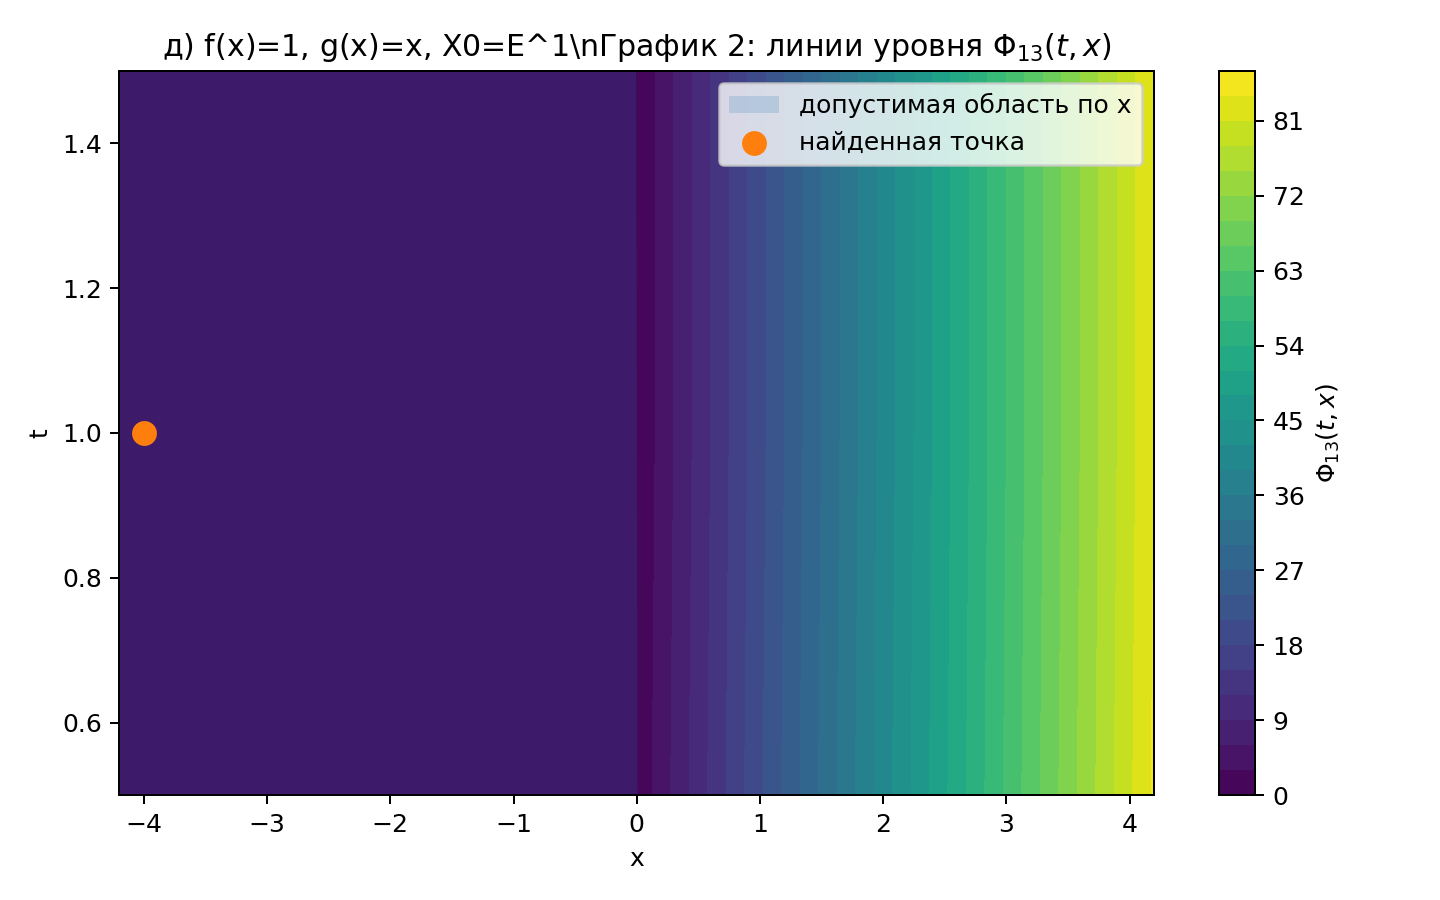

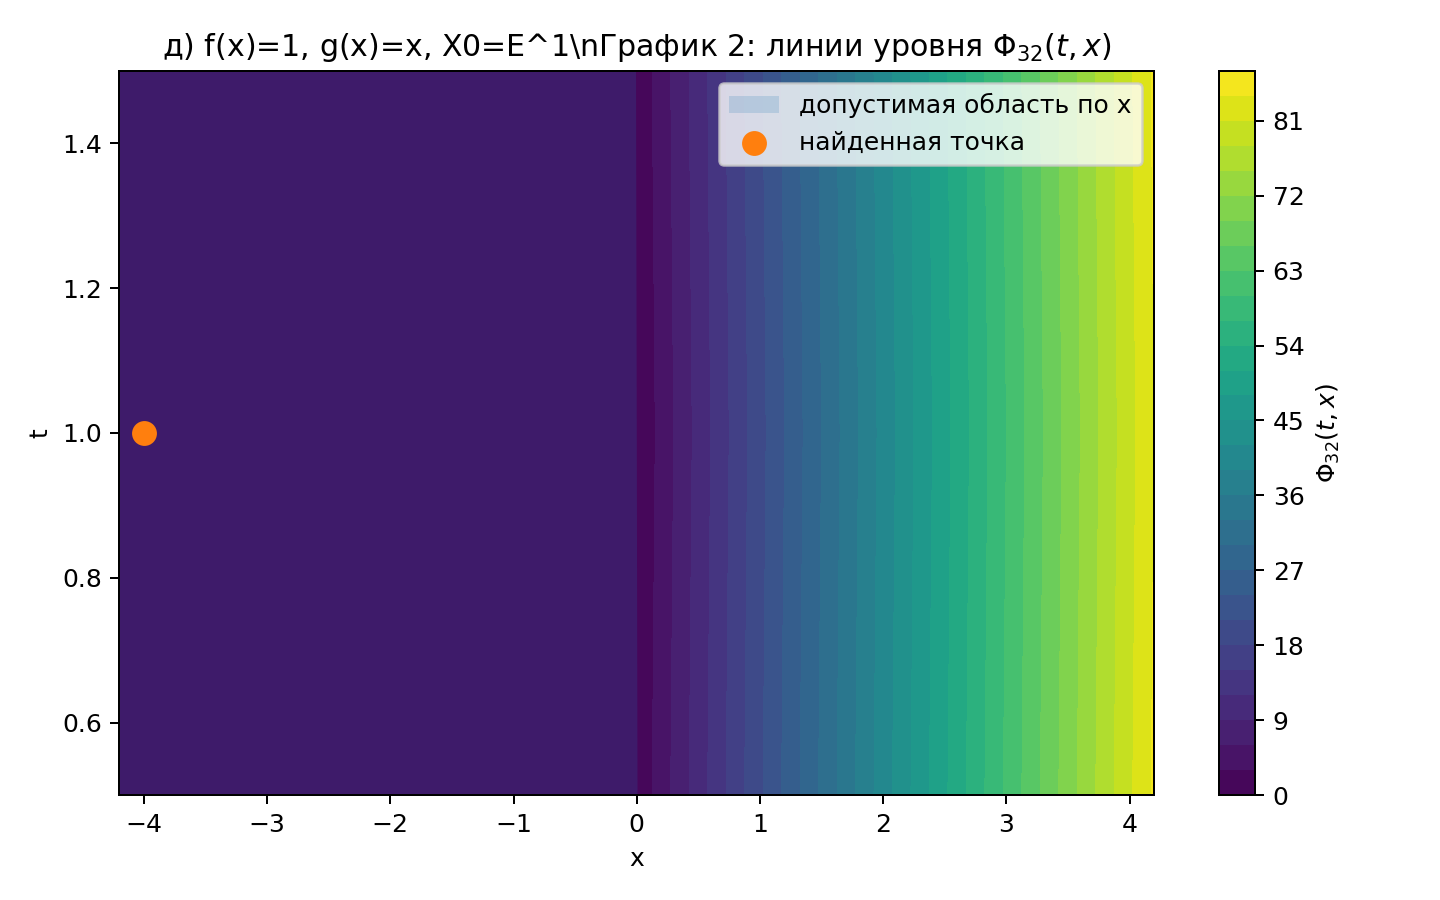

In [7]:

from IPython.display import Image, display
for name in [
    "graphs/d_graph1_phi13.png",
    "graphs/d_graph1_phi32.png",
    "graphs/d_graph2_phi13.png",
    "graphs/d_graph2_phi32.png",
]:
    display(Image(filename=name))
